# 1. Date-Based Feature Engineering

## Business Question

Can temporal characteristics of a date help the model learn recurring demand patterns?

A raw date contains several pieces of information that may influence retail demand, including yearly trends, monthly seasonality, weekly patterns and weekend effects.

Therefore, the Date column is decomposed into meaningful temporal features such as Year, Month, Day, WeekOfYear, Quarter and IsWeekend.

These features allow machine-learning models to learn temporal patterns that would otherwise be difficult to extract from a raw date value.

In [2]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)

train = pd.read_csv("../data/train.csv")
store = pd.read_csv("../data/store.csv")

df = pd.merge(
    train,
    store,
    on="Store",
    how="left"
)

print(df.shape)

(1017209, 18)


C:\Users\Anubhav\AppData\Local\Temp\ipykernel_78188\2192998845.py:6: DtypeWarning: Columns (0: StateHoliday) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv("../data/train.csv")


In [3]:
df["Date"] = pd.to_datetime(df["Date"])

In [4]:
df["Year"] = df["Date"].dt.year

df["Month"] = df["Date"].dt.month

df["Day"] = df["Date"].dt.day

df["WeekOfYear"] = df["Date"].dt.isocalendar().week.astype(int) #Create a new column called WeekOfYear 
#containing the week number of each date. astype(int) is required to conver the pandas integer type to python integer type

df["Quarter"] = df["Date"].dt.quarter

df["IsWeekend"] = df["DayOfWeek"].isin([6, 7]).astype(int)#create a column called IsWeekend to tell whther 
#the date was a weekday or not  

In [5]:
df[
    [
        "Date",
        "Year",
        "Month",
        "Day",
        "DayOfWeek",
        "WeekOfYear",
        "Quarter",
        "IsWeekend"
    ]
].head(10)

,Date,Year,Month,Day,DayOfWeek,WeekOfYear,Quarter,IsWeekend
0,2015-07-31,2015,7,31,5,31,3,0
1,2015-07-31,2015,7,31,5,31,3,0
2,2015-07-31,2015,7,31,5,31,3,0
3,2015-07-31,2015,7,31,5,31,3,0
4,2015-07-31,2015,7,31,5,31,3,0
5,2015-07-31,2015,7,31,5,31,3,0
6,2015-07-31,2015,7,31,5,31,3,0
7,2015-07-31,2015,7,31,5,31,3,0
8,2015-07-31,2015,7,31,5,31,3,0
9,2015-07-31,2015,7,31,5,31,3,0


# 2. Store and Promotion Feature Engineering

## Business Question

Can store characteristics, competition maturity and promotion duration provide additional information for predicting future demand?

The raw dataset contains information about competition and promotional programs, but some variables describe these concepts indirectly.

Therefore, additional features are created to represent:

- How long a competitor has been operating.
- How long a store has participated in Promo2.

These features provide the model with more directly interpretable information about the competitive and promotional environment surrounding each store.

In [6]:
df["CompetitionOpenDate"] = pd.to_datetime( #this datetime convert this whole thing to a proper date 
    dict(
        year=df["CompetitionOpenSinceYear"],
        month=df["CompetitionOpenSinceMonth"],
        day=1 # we only have information about year and month but not the exact day. so we assume the first day
        #of the month so that's why 1
    ),
    errors="coerce" # some values in this column are NAN but pandas could not decode this NAN values so with 
    #this we say you do not have to throw an error just convert the NAN values to NAT(not a time)
)

In [7]:
df["CompetitionOpenMonths"] = (
    (df["Date"].dt.year - df["CompetitionOpenDate"].dt.year) * 12
    + (df["Date"].dt.month - df["CompetitionOpenDate"].dt.month)
)
#this is nothing but suppose competition start date = may 2012
#sales date = july 2015
#so no. of years passed= 2015-2012 = 3
#convert it into months= 3*12= 36
#now months gap= july-may= 7-5= 2
#thus total months gap= 36 + 2= 38
#we could have done simply date-opendate = but it would give us in no. of days, we want it in more precise in months


In [8]:
df["CompetitionOpenMonths"] = df["CompetitionOpenMonths"].fillna(0) #fills all those NAT values,
#this 0 does not mean that the competitor opened today,it means we do not have a valid competition opening date 
# so we encoded it with 0

df["CompetitionOpenMonths"] = df["CompetitionOpenMonths"].clip(lower=0)#suppose we have competitondate that 
#opens after the sales date , this could give us a negative value, so clip those negative values to 0

see we will be creating  a new column promo2Active
| Feature         | Question it answers                                         | Nature      |
| --------------- | ----------------------------------------------------------- | ----------- |
| `Promo`         | Is there a promotion **today**?                             | Daily       |
| `Promo2`        | Is the store enrolled in a **recurring promotion program**? | Store-level |
| `PromoInterval` | **When** does that recurring promotion run?                 | Schedule    |

means with promo2active we are simply calculating on which months promo2 program is active or not
we are basically converting that promointerval months thing to a numerical column.



In [9]:
df["PromoInterval"].value_counts(dropna=False)

PromoInterval
NaN                 508031
Jan,Apr,Jul,Oct     293122
Feb,May,Aug,Nov     118596
Mar,Jun,Sept,Dec     97460
Name: count, dtype: int64

In [10]:
promo_intervals = {
    "Jan,Apr,Jul,Oct": [1, 4, 7, 10],
    "Feb,May,Aug,Nov": [2, 5, 8, 11],
    "Mar,Jun,Sept,Dec": [3, 6, 9, 12]
}

In [11]:
df["Promo2Active"] = df.apply(
    lambda row: (
        row["Promo2"] == 1
        and row["Month"] in promo_intervals.get(row["PromoInterval"], [])
    ),
    axis=1
).astype(int)

Is Promo2 = 1?
       AND
Is this month's number present in that store's PromoInterval?
       ↓
Yes → 1
No  → 0

this is the basic code logic for the above code

In [12]:
df[
    [
        "Date",
        "Promo2",
        "PromoInterval",
        "Month",
        "Promo2Active"
    ]
].head(20)

,Date,Promo2,PromoInterval,Month,Promo2Active
0,2015-07-31,0,NaN,7,0
1,2015-07-31,1,"Jan,Apr,Jul,Oct",7,1
2,2015-07-31,1,"Jan,Apr,Jul,Oct",7,1
3,2015-07-31,0,NaN,7,0
4,2015-07-31,0,NaN,7,0
5,2015-07-31,0,NaN,7,0
6,2015-07-31,0,NaN,7,0
7,2015-07-31,0,NaN,7,0
8,2015-07-31,0,NaN,7,0
9,2015-07-31,0,NaN,7,0


# 4. Holiday Feature Engineering

## Business Question

Can holiday information help the model identify changes in retail demand?

State holidays may significantly affect store traffic and purchasing behaviour, while school holidays can change customer availability and shopping patterns.

The StateHoliday variable contains categorical codes representing different holiday types. Therefore, an additional binary feature, IsStateHoliday, is created to indicate whether a state holiday is occurring on a particular date.

SchoolHoliday is already represented as a binary variable and therefore does not require additional transformation.

we will create a new column, "isstateholiday" to mark the binary coding 0- no , 1- yes
isstateholiday tells us whether there is a stateholiday or not
stateholiday represents what type of holiday it is
a= public holiday
b= easter
c=christmas


In [13]:
df["StateHoliday"].value_counts(dropna=False) # 0 means no state holiday, but here some 0 are numeriic and some 0 have string dtype
#always remeber this kind of small details, otherwise an error will be thrown and you will just wonder about

StateHoliday
0    855087
0    131072
a     20260
b      6690
c      4100
Name: count, dtype: int64

In [14]:
df["StateHoliday"].map(type).value_counts() # we have this much int rows and that much string rows

StateHoliday
<class 'str'>    886137
<class 'int'>    131072
Name: count, dtype: int64

In [15]:
df["StateHoliday"] = df["StateHoliday"].astype(str)

In [16]:
df["StateHoliday"].value_counts()

StateHoliday
0    986159
a     20260
b      6690
c      4100
Name: count, dtype: int64

In [17]:
df["IsStateHoliday"] = (df["StateHoliday"] != "0").astype(int)

In [18]:
df["IsStateHoliday"].value_counts()

IsStateHoliday
0    986159
1     31050
Name: count, dtype: int64

In [19]:
df["CompetitionDistance"].describe()

count    1.014567e+06
mean     5.430086e+03
std      7.715324e+03
min      2.000000e+01
25%      7.100000e+02
50%      2.330000e+03
75%      6.890000e+03
max      7.586000e+04
Name: CompetitionDistance, dtype: float64

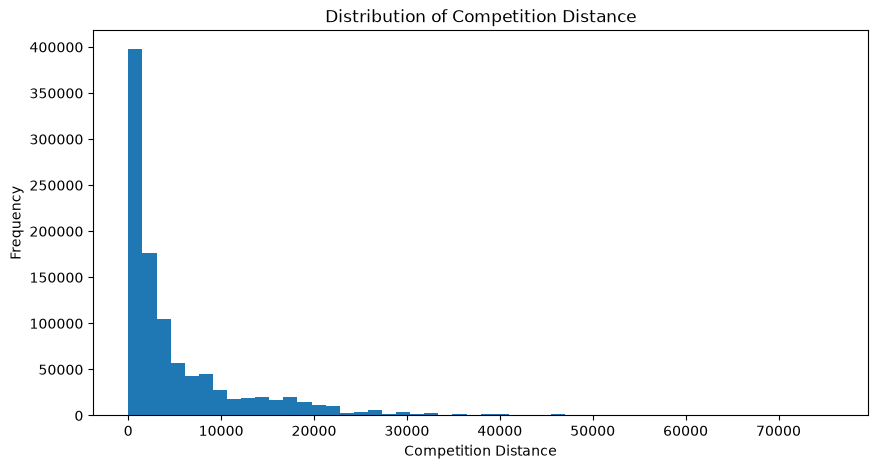

In [20]:
import matplotlib.pyplot as plt
df["CompetitionDistance"].plot(
    kind="hist",
    bins=50,
    figsize=(10, 5)
)

plt.title("Distribution of Competition Distance")
plt.xlabel("Competition Distance")
plt.ylabel("Frequency")
plt.show()

For our model, we can use the median to fill these few missing values because:

the feature is heavily right-skewed
median is less affected by those huge distances
only ~0.26% is missing

In [21]:
median_distance = df["CompetitionDistance"].median()

df["CompetitionDistance"] = df["CompetitionDistance"].fillna(
    median_distance
)

In [22]:
df["StoreType"].value_counts()

StoreType
a    551627
d    312912
c    136840
b     15830
Name: count, dtype: int64

In [23]:
df["Assortment"].value_counts()

Assortment
a    537445
c    471470
b      8294
Name: count, dtype: int64

In [24]:
df["StateHoliday"].value_counts()

StateHoliday
0    986159
a     20260
b      6690
c      4100
Name: count, dtype: int64

we used here one hot encoding to make the categorical features int obinary numerical features
1. Label / Ordinal Encoding

Example:

StoreType


a → 0
b → 1
c → 2
d → 3

Very compact — only one column.

But the problem is that it introduces an artificial ordering:

d > c > b > a

There isn't actually such a relationship.

So I wouldn't use this blindly.

2. Target Encoding

This is much more interesting for our project.

Instead of:

StoreType
a
b
c
d

we could replace each category with something related to the target.

For example, conceptually:

StoreType a → average historical sales for type a
StoreType b → average historical sales for type b
StoreType c → average historical sales for type c
StoreType d → average historical sales for type d

That gives us one numerical column instead of four.

But there is a major danger:

Data leakage.

We're predicting Sales, so if we calculate:

StoreType a → average Sales

using the entire dataset, we're allowing information from the target to leak into our features.

For a forecasting project, we have to be extremely careful about this.

3. Frequency Encoding

We could encode a category by how frequently it occurs.

For example:

StoreType a → 551627 / 1017209
StoreType b → 15830 / 1017209
...

Again, only one column.

But this doesn't actually tell the model what makes store type a different from b; it mostly tells it how common the category is.

So it's not particularly compelling here.

In the Rossmann dataset, Assortment describes the level/type of product variety that a store offers.

But there's a small nuance: the values a, b, and c are categories describing the assortment level, not the actual number of different products.

So conceptually:

Assortment	Meaning
a	Basic assortment
b	Extra assortment
c	Extended assortment



pd.get_dummies converts categorical text columns in a pandas DataFrame into separate numeric 0 and 1 columns. This process is called one-hot encoding. 
It lets machine learning models understand text categories like store types or holidays.
How It Works:
Takes text values and makes a new column for each unique value.Puts a 1 if the row has that value, and a 0 if it does not.
Removes the original text columns and keeps the rest of your data safe.
Example Breakdowndf: Your current table of data.columns=[...]: The specific text columns you want to change into numbers.
dtype=int: Makes the new 0 and 1 columns use integer numbers instead of True/False words.

In [25]:
df = pd.get_dummies(
    df,
    columns=["StoreType", "Assortment", "StateHoliday"],
    dtype=int
)

In [26]:
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,SchoolHoliday,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Year,Month,Day,WeekOfYear,Quarter,IsWeekend,CompetitionOpenDate,CompetitionOpenMonths,Promo2Active,IsStateHoliday,StoreType_a,StoreType_b,StoreType_c,StoreType_d,Assortment_a,Assortment_b,Assortment_c,StateHoliday_0,StateHoliday_a,StateHoliday_b,StateHoliday_c
0,1,5,2015-07-31,5263,555,1,1,1,1270.0,9.0,2008.0,0,NaN,NaN,NaN,2015,7,31,31,3,0,2008-09-01,82.0,0,0,0,0,1,0,1,0,0,1,0,0,0
1,2,5,2015-07-31,6064,625,1,1,1,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct",2015,7,31,31,3,0,2007-11-01,92.0,1,0,1,0,0,0,1,0,0,1,0,0,0
2,3,5,2015-07-31,8314,821,1,1,1,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct",2015,7,31,31,3,0,2006-12-01,103.0,1,0,1,0,0,0,1,0,0,1,0,0,0
3,4,5,2015-07-31,13995,1498,1,1,1,620.0,9.0,2009.0,0,NaN,NaN,NaN,2015,7,31,31,3,0,2009-09-01,70.0,0,0,0,0,1,0,0,0,1,1,0,0,0
4,5,5,2015-07-31,4822,559,1,1,1,29910.0,4.0,2015.0,0,NaN,NaN,NaN,2015,7,31,31,3,0,2015-04-01,3.0,0,0,1,0,0,0,1,0,0,1,0,0,0


# 6. Lag Features

## Business Question

Can a store's recent historical sales help predict its future demand?

Retail sales often exhibit temporal dependence and weekly seasonality. Therefore, lag features are created to provide the model with information about the store's historical sales.

The following features are created:

- Sales_Lag_1: sales from the previous day.
- Sales_Lag_7: sales from the same day of the previous week.
- Sales_Lag_14: sales from two weeks earlier.

Lag features are calculated separately for each store to preserve store-specific sales history.

In [27]:
df = df.sort_values(["Store", "Date"]).reset_index(drop=True) #here we sort the sort wrt to the date

df["Sales_Lag_1"] = df.groupby("Store")["Sales"].shift(1) #this shift function does is,For each individual store, take its Sales column and move it down by one row.
df["Sales_Lag_7"] = df.groupby("Store")["Sales"].shift(7)
df["Sales_Lag_14"] = df.groupby("Store")["Sales"].shift(14)

In [28]:
df[
    ["Store", "Date", "Sales", "Sales_Lag_1", "Sales_Lag_7", "Sales_Lag_14"]
].head(10)

,Store,Date,Sales,Sales_Lag_1,Sales_Lag_7,Sales_Lag_14
0,1,2013-01-01,0,NaN,NaN,NaN
1,1,2013-01-02,5530,0.0,NaN,NaN
2,1,2013-01-03,4327,5530.0,NaN,NaN
3,1,2013-01-04,4486,4327.0,NaN,NaN
4,1,2013-01-05,4997,4486.0,NaN,NaN
5,1,2013-01-06,0,4997.0,NaN,NaN
6,1,2013-01-07,7176,0.0,NaN,NaN
7,1,2013-01-08,5580,7176.0,0.0,NaN
8,1,2013-01-09,5471,5580.0,5530.0,NaN
9,1,2013-01-10,4892,5471.0,4327.0,NaN


# 7. Rolling Sales Features

## Business Question

Can the recent sales trend of a store help predict its future demand?

Lag features provide sales from specific previous days, but a single previous day's sales can be noisy. Rolling features summarize the store's recent sales behaviour over a period of time.

We will create rolling average sales features based only on historical observations:

- `Sales_Rolling_7` → average sales over the previous 7 days
- `Sales_Rolling_14` → average sales over the previous 14 days
- `Sales_Rolling_30` → average sales over the previous 30 days

These features help the model understand whether a store's recent demand is generally high, low, or stable.

### Important: Avoiding Data Leakage

The current day's `Sales` must not be included when calculating rolling features because `Sales` is the target variable we are trying to predict.

Therefore, rolling features will be calculated using lagged sales so that only information available **before the prediction date** is used.

This ensures that the forecasting model does not have access to future information.

Why do we need both lag features AND rolling features?

Because:

Sales_Lag_7

tells us about one specific point in the past.

Whereas:

Sales_Rolling_7

tells us about the overall recent trend.

What can we conclude by looking at both together?

Sales 7 days ago       = 5,530
Previous 7-day average = 4,585

So:

5,530 > 4,585

The same day last week had higher-than-usual sales compared with the recent weekly average.

That tells our model something like:

"This store's corresponding day last week was unusually strong relative to its recent baseline."

And then the actual Jan 9 sales were:

5,471

which is also close to the previous week's:

5,530

So in this particular example, the previous week's corresponding sales were a very useful signal.


In [29]:
df["Sales_Rolling_7"] = (
    df.groupby("Store")["Sales_Lag_1"]
      .transform(lambda x: x.rolling(7).mean())
)

df.groupby("Store")
What it does: Groups the DataFrame rows together based on the unique values in the "Store" column.

Why it matters: This ensures that all subsequent calculations (like rolling windows) are performed independently for each store, preventing data from "leaking" or rolling over between different stores (e.g., the last days of Store A won't be mixed into the rolling calculation for Store B).

3. ["Sales_Lag_1"]
What it does: Selects only the "Sales_Lag_1" column from each group for the upcoming calculations, ignoring all other columns in the DataFrame.

4. .transform(...)
What it does: Applies a function to each group and then broadcasts or aligns the results back to the original index shape of the DataFrame.

Why it matters: Unlike .agg() (which shrinks the DataFrame down to one row per group) or .apply() (which can return irregularly shaped outputs depending on the function), .transform() guarantees that the output has the exact same number of rows as the original df, making it seamless to assign back into a new column.

5. lambda x: x.rolling(7).mean()
What it does: Defines an anonymous inline function where x represents the "Sales_Lag_1" series for a single store:

.rolling(7): Creates a sliding window of size 7 (meaning it looks at the current row and the 6 preceding rows within that specific store's group).

.mean(): Calculates the arithmetic average of the values inside that 7-period window. For the first 6 rows of any store (where fewer than 7 prior observations exist), it will automatically return NaN (Not a Number) because there aren't enough data points to fill the window yet.

In [30]:
df[
    ["Store", "Date", "Sales", "Sales_Lag_1", "Sales_Rolling_7"]
].head(10) #to calculate jan 9 rolling features we take sales data from jan 2 to jan 8, 
#not included jan9 because we have to predict it only.

,Store,Date,Sales,Sales_Lag_1,Sales_Rolling_7
0,1,2013-01-01,0,NaN,NaN
1,1,2013-01-02,5530,0.0,NaN
2,1,2013-01-03,4327,5530.0,NaN
3,1,2013-01-04,4486,4327.0,NaN
4,1,2013-01-05,4997,4486.0,NaN
5,1,2013-01-06,0,4997.0,NaN
6,1,2013-01-07,7176,0.0,NaN
7,1,2013-01-08,5580,7176.0,3788.000000
8,1,2013-01-09,5471,5580.0,4585.142857
9,1,2013-01-10,4892,5471.0,4576.714286


In [31]:
df["Sales_Rolling_14"] = (
    df.groupby("Store")["Sales_Lag_1"]
      .transform(lambda x: x.rolling(14).mean())
)

df["Sales_Rolling_30"] = (
    df.groupby("Store")["Sales_Lag_1"]
      .transform(lambda x: x.rolling(30).mean())
)

df[
    [
        "Store",
        "Date",
        "Sales",
        "Sales_Lag_7",
        "Sales_Rolling_7",
        "Sales_Rolling_14",
        "Sales_Rolling_30"
    ]
].iloc[30:40]

,Store,Date,Sales,Sales_Lag_7,Sales_Rolling_7,Sales_Rolling_14,Sales_Rolling_30
30,1,2013-01-31,4709,5195.0,4108.571429,4200.357143,4124.066667
31,1,2013-02-01,5633,5586.0,4039.142857,4247.857143,4281.033333
32,1,2013-02-02,5970,5598.0,4045.857143,4355.428571,4284.466667
33,1,2013-02-03,0,0.0,4099.000000,4411.714286,4339.233333
34,1,2013-02-04,7032,4055.0,4099.000000,4411.714286,4189.700000
35,1,2013-02-05,6049,3725.0,4524.285714,4528.714286,4257.533333
36,1,2013-02-06,6140,4601.0,4856.285714,4552.214286,4459.166667
37,1,2013-02-07,5499,4709.0,5076.142857,4592.357143,4424.633333
38,1,2013-02-08,5681,5633.0,5189.000000,4614.071429,4421.933333
39,1,2013-02-09,5370,5970.0,5195.857143,4620.857143,4428.933333


## 8. Handling Missing Values from Lag and Rolling Features

Lag and rolling features naturally produce missing values at the beginning of each store's historical record because sufficient past observations are not available.

For example:

- `Sales_Lag_1` is unavailable for the first observation of each store.
- `Sales_Lag_7` is unavailable for the first 7 observations.
- `Sales_Lag_14` is unavailable for the first 14 observations.
- `Sales_Rolling_7`, `Sales_Rolling_14`, and `Sales_Rolling_30` require sufficient historical observations before they can be calculated.

These are not errors or missing values in the original dataset. They occur because historical information does not exist before the beginning of a store's recorded history.

Since these observations cannot provide the required historical features, they will be removed before model training rather than artificially imputed.

In [32]:
df.isnull().sum().sort_values(ascending=False)

Promo2SinceWeek              508031
Promo2SinceYear              508031
PromoInterval                508031
CompetitionOpenSinceYear     323348
CompetitionOpenSinceMonth    323348
CompetitionOpenDate          323348
Sales_Rolling_30              33450
Sales_Lag_14                  15610
Sales_Rolling_14              15610
Sales_Lag_7                    7805
Sales_Rolling_7                7805
Sales_Lag_1                    1115
CompetitionDistance               0
Open                              0
Sales                             0
Customers                         0
Date                              0
DayOfWeek                         0
Store                             0
SchoolHoliday                     0
Promo                             0
WeekOfYear                        0
Day                               0
Promo2                            0
Month                             0
Year                              0
StoreType_a                       0
IsStateHoliday              

We're not dropping rows because "NaN is bad."

We're dropping them because:

A forecasting observation without the required historical context cannot be used for a model whose features explicitly depend on that history.

Why this is acceptable

We have:

1,017,209 total observations

and:

33,450 rows lack the 30-day history.

That's about:

3.29% removed → 96.71% retained.

For a dataset of over one million observations, retaining ~97% of the data is perfectly reasonable.

More importantly, we're not randomly losing data.

We're removing:

the beginning of each store's history where the required historical context does not exist.

That's methodologically clean.

In [33]:
model_df = df.dropna(
    subset=["Sales_Rolling_30"]
).copy() # we created a copy of our dataset with rows that will be specifically used in training

In [34]:
print("Original shape:", df.shape)
print("Model shape:", model_df.shape)

Original shape: (1017209, 42)
Model shape: (983759, 42)


In [35]:
model_df[
    [
        "Sales_Lag_1",
        "Sales_Lag_7",
        "Sales_Lag_14",
        "Sales_Rolling_7",
        "Sales_Rolling_14",
        "Sales_Rolling_30"
    ]
].isnull().sum()

Sales_Lag_1         0
Sales_Lag_7         0
Sales_Lag_14        0
Sales_Rolling_7     0
Sales_Rolling_14    0
Sales_Rolling_30    0
dtype: int64

In [36]:
model_df.columns.tolist()

['Store',
 'DayOfWeek',
 'Date',
 'Sales',
 'Customers',
 'Open',
 'Promo',
 'SchoolHoliday',
 'CompetitionDistance',
 'CompetitionOpenSinceMonth',
 'CompetitionOpenSinceYear',
 'Promo2',
 'Promo2SinceWeek',
 'Promo2SinceYear',
 'PromoInterval',
 'Year',
 'Month',
 'Day',
 'WeekOfYear',
 'Quarter',
 'IsWeekend',
 'CompetitionOpenDate',
 'CompetitionOpenMonths',
 'Promo2Active',
 'IsStateHoliday',
 'StoreType_a',
 'StoreType_b',
 'StoreType_c',
 'StoreType_d',
 'Assortment_a',
 'Assortment_b',
 'Assortment_c',
 'StateHoliday_0',
 'StateHoliday_a',
 'StateHoliday_b',
 'StateHoliday_c',
 'Sales_Lag_1',
 'Sales_Lag_7',
 'Sales_Lag_14',
 'Sales_Rolling_7',
 'Sales_Rolling_14',
 'Sales_Rolling_30']

## 9. Final Feature Audit

Before preparing the data for model training, all engineered features are checked for:

- Remaining missing values
- Impossible or suspicious values
- Incorrect data types
- Redundant raw features that have already been transformed
- Consistency of the historical sales features

This ensures that the final modeling dataset contains only meaningful and valid information.

In [37]:
model_df.isnull().sum().sort_values(ascending=False)

Promo2SinceWeek              491711
Promo2SinceYear              491711
PromoInterval                491711
CompetitionOpenSinceYear     312728
CompetitionOpenSinceMonth    312728
CompetitionOpenDate          312728
DayOfWeek                         0
Date                              0
Customers                         0
Store                             0
CompetitionDistance               0
SchoolHoliday                     0
Promo                             0
Open                              0
Sales                             0
Promo2                            0
Month                             0
Year                              0
Day                               0
WeekOfYear                        0
Quarter                           0
IsWeekend                         0
CompetitionOpenMonths             0
Promo2Active                      0
IsStateHoliday                    0
StoreType_a                       0
StoreType_b                       0
StoreType_c                 

In [38]:
model_df["CompetitionOpenMonths"].describe()

count    983759.000000
mean         42.321483
std          65.397410
min           0.000000
25%           0.000000
50%          17.000000
75%          73.000000
max        1386.000000
Name: CompetitionOpenMonths, dtype: float64

In [39]:
model_df["CompetitionOpenMonths"].min(), model_df["CompetitionOpenMonths"].max()

(np.float64(0.0), np.float64(1386.0))

In [40]:
model_df["CompetitionOpenMonths"].isnull().sum()

np.int64(0)

In [41]:
for col in [
    "Open",
    "Promo",
    "Promo2",
    "SchoolHoliday",
    "Promo2Active",
    "IsStateHoliday"
]:
    print(col, model_df[col].unique())

Open [1 0]
Promo [0 1]
Promo2 [0 1]
SchoolHoliday [0 1]
Promo2Active [0 1]
IsStateHoliday [0 1]


In [42]:
lag_cols = [
    "Sales_Lag_1",
    "Sales_Lag_7",
    "Sales_Lag_14",
    "Sales_Rolling_7",
    "Sales_Rolling_14",
    "Sales_Rolling_30"
]

model_df[lag_cols].isnull().sum()

Sales_Lag_1         0
Sales_Lag_7         0
Sales_Lag_14        0
Sales_Rolling_7     0
Sales_Rolling_14    0
Sales_Rolling_30    0
dtype: int64

In [43]:
[col for col in model_df.columns
 if col.startswith(("StoreType_", "Assortment_", "StateHoliday_"))]

['StoreType_a',
 'StoreType_b',
 'StoreType_c',
 'StoreType_d',
 'Assortment_a',
 'Assortment_b',
 'Assortment_c',
 'StateHoliday_0',
 'StateHoliday_a',
 'StateHoliday_b',
 'StateHoliday_c']

In [44]:
model_df.info()

<class 'pandas.DataFrame'>
Index: 983759 entries, 30 to 1017208
Data columns (total 42 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   Store                      983759 non-null  int64         
 1   DayOfWeek                  983759 non-null  int64         
 2   Date                       983759 non-null  datetime64[us]
 3   Sales                      983759 non-null  int64         
 4   Customers                  983759 non-null  int64         
 5   Open                       983759 non-null  int64         
 6   Promo                      983759 non-null  int64         
 7   SchoolHoliday              983759 non-null  int64         
 8   CompetitionDistance        983759 non-null  float64       
 9   CompetitionOpenSinceMonth  671031 non-null  float64       
 10  CompetitionOpenSinceYear   671031 non-null  float64       
 11  Promo2                     983759 non-null  int64         
 12  Pr

In [45]:
model_df[
    ["Store", "Date", "CompetitionOpenMonths",
     "CompetitionOpenSinceMonth", "CompetitionOpenSinceYear"]
].sort_values(
    "CompetitionOpenMonths",
    ascending=False
).head(10)

,Store,Date,CompetitionOpenMonths,CompetitionOpenSinceMonth,CompetitionOpenSinceYear
742504,815,2015-07-14,1386.0,1.0,1900.0
742503,815,2015-07-13,1386.0,1.0,1900.0
742502,815,2015-07-12,1386.0,1.0,1900.0
742501,815,2015-07-11,1386.0,1.0,1900.0
742521,815,2015-07-31,1386.0,1.0,1900.0
742520,815,2015-07-30,1386.0,1.0,1900.0
742519,815,2015-07-29,1386.0,1.0,1900.0
742518,815,2015-07-28,1386.0,1.0,1900.0
742517,815,2015-07-27,1386.0,1.0,1900.0
742515,815,2015-07-25,1386.0,1.0,1900.0


Store 815 is the problem

Your output shows:

Store = 815
CompetitionOpenSinceMonth = 1
CompetitionOpenSinceYear = 1900
CompetitionOpenMonths = 1386

That means our calculation interpreted the dataset's 1900-01 value literally and concluded:

"The competitor has been operating for 115+ years."

That's not a sensible business feature.

Interestingly, this isn't an error you introduced. The original Rossmann store data actually contains 1900 as a special/sentinel value for competition information; exploratory analyses of the original dataset explicitly note the single 1900 competition entry.

So we should not let 1386 months enter our model as if it were a real competition duration.

we did competition open since months as 0 
Why 0?

Because in our engineered feature, we're using:

months of competition presence relevant to the store

and we don't have reliable information for Store 815. More importantly, 0 is a much safer representation than inventing a 115-year competition history.

In [46]:
model_df.loc[
    model_df["Store"] == 815,
    "CompetitionOpenMonths"
] = 0

In [47]:
model_df.loc[
    model_df["Store"] == 815,
    "CompetitionOpenMonths"
].unique()

array([0.])

In [48]:
model_df["CompetitionOpenMonths"].describe()

count    983759.000000
mean         41.307476
std          54.517133
min           0.000000
25%           0.000000
50%          17.000000
75%          73.000000
max         645.000000
Name: CompetitionOpenMonths, dtype: float64

In [49]:
columns_to_drop = [
    "Customers",
    "Date",
    "CompetitionOpenSinceMonth",
    "CompetitionOpenSinceYear",
    "CompetitionOpenDate",
    "Promo2SinceWeek",
    "Promo2SinceYear",
    "PromoInterval",
    "Quarter",
    "IsWeekend"
]

model_df = model_df.drop(columns=columns_to_drop)

In [50]:
model_df = model_df.reset_index(drop=True)

In [51]:
model_df.shape
model_df.columns.tolist()

['Store',
 'DayOfWeek',
 'Sales',
 'Open',
 'Promo',
 'SchoolHoliday',
 'CompetitionDistance',
 'Promo2',
 'Year',
 'Month',
 'Day',
 'WeekOfYear',
 'CompetitionOpenMonths',
 'Promo2Active',
 'IsStateHoliday',
 'StoreType_a',
 'StoreType_b',
 'StoreType_c',
 'StoreType_d',
 'Assortment_a',
 'Assortment_b',
 'Assortment_c',
 'StateHoliday_0',
 'StateHoliday_a',
 'StateHoliday_b',
 'StateHoliday_c',
 'Sales_Lag_1',
 'Sales_Lag_7',
 'Sales_Lag_14',
 'Sales_Rolling_7',
 'Sales_Rolling_14',
 'Sales_Rolling_30']

In [52]:
print("Shape:", model_df.shape)
print("Missing values:", model_df.isnull().sum().sum())

Shape: (983759, 32)
Missing values: 0


model_df
│
├── Date ───────────────→ used for chronological split
│
├── Sales ──────────────→ target (y)
│
└── Features ───────────→ model inputs (X)

Date is metadata used to organize the forecasting experiment, not necessarily a model feature.

In [55]:
train["Date"] = pd.to_datetime(train["Date"])

In [56]:
train["Date"].dtype

dtype('<M8[us]')

In [57]:
date_lookup = train[["Store", "Date"]].copy()

date_lookup["Year"] = date_lookup["Date"].dt.year
date_lookup["Month"] = date_lookup["Date"].dt.month
date_lookup["Day"] = date_lookup["Date"].dt.day

In [58]:
model_df = model_df.merge(
    date_lookup,
    on=["Store", "Year", "Month", "Day"],
    how="left"
)

In [59]:
print(model_df["Date"].isnull().sum())

0


In [60]:
print(model_df[["Store", "Date", "Year", "Month", "Day"]].head(10))

   Store       Date  Year  Month  Day
0      1 2013-01-31  2013      1   31
1      1 2013-02-01  2013      2    1
2      1 2013-02-02  2013      2    2
3      1 2013-02-03  2013      2    3
4      1 2013-02-04  2013      2    4
5      1 2013-02-05  2013      2    5
6      1 2013-02-06  2013      2    6
7      1 2013-02-07  2013      2    7
8      1 2013-02-08  2013      2    8
9      1 2013-02-09  2013      2    9


In [61]:
model_df.shape

(983759, 33)

In [62]:
print(
    model_df.duplicated(
        subset=["Store", "Date"]
    ).sum()
)

0


In [63]:

model_df.to_csv(
    "../data/processed/model_data.csv",
    index=False
)

Q) "Why should I believe your engineered features will actually improve forecasting accuracy?"

This is where you should not claim something we haven't demonstrated yet.

The correct answer is:

"I don't assume that every engineered feature will improve the model. I created them based on the temporal and business characteristics identified during EDA, and I'll validate their usefulness empirically."

Then explain:

Why we created them

For example:

Sales_Lag_1

Because yesterday's demand is likely informative about today's demand.

Sales_Lag_7

Because our EDA showed a strong day-of-week pattern, so sales from the same weekday of the previous week can be informative.

Sales_Rolling_7

Captures the store's recent demand level rather than relying on one noisy observation.

Sales_Rolling_30

Provides a longer-term baseline.

CompetitionDistance

Represents the competitive environment.

Promo / Promo2Active

Represent promotional activity that can influence demand.

So every feature has a business or temporal hypothesis behind it.

But then comes the most important part:
We test the hypothesis.

We'll establish a baseline model and compare it against models with our engineered features.

For example:

Baseline
   ↓
MAE = X
RMSE = Y


        vs.


Engineered features
   ↓
MAE = A
RMSE = B

If:

A < X
B < Y

then our features have demonstrated value.

We can also examine:

XGBoost feature importance
permutation importance
validation error
ablation experiments
whether removing individual feature groups hurts performance
Strong interview answer:

"I wouldn't claim that all engineered features improve accuracy beforehand. Each feature was created based on a business or temporal hypothesis identified during EDA. We will validate those hypotheses using a time-based validation set and compare model performance with and without the engineered features. Features that don't contribute meaningful predictive value can then be removed. Therefore, feature engineering is treated as an empirical process rather than an assumption."

That's the answer I'd want you to give in an interview. 🟢

Q)"You created lag features using the entire dataset before performing your train/validation split. How do you know you haven't introduced data leakage?"

This is a very good interview question, and there's an important nuance.

The proper answer:

"The lag features themselves were generated chronologically within each store using only past observations. For example, Sales_Lag_7 for a given date uses the sales from seven days earlier, and the rolling features use only historical sales through the previous day. Therefore, the feature calculation itself does not use the target value of the current date."

However, there's an additional issue:

"For a rigorous forecasting pipeline, I should perform the temporal split first and ensure that feature construction for validation uses only information that would actually have been available at prediction time."

This distinction is very important.

Why our shift() approach is safe for the historical sequence

Suppose:

July 10 → Sales = 5,000
July 11 → Sales = 5,500
July 12 → Sales = 6,000

For July 12:

Sales_Lag_1 = 5,500

It does not use July 12's Sales = 6,000.

Similarly:

Sales_Rolling_7

was constructed from Sales_Lag_1, so today's target isn't included.

Therefore, we have not accidentally used the current day's target to construct its features.

But here's the subtle point an interviewer may test

Imagine our validation starts on:

2015-07-01

For predicting July 1, using June 30's actual sales is legitimate because June 30 has already happened.

So we don't need to pretend that all validation lag values must be NaN.

The historical observations before the validation cutoff are legitimately available information.

The important rule is:

Never use information from July 2, July 3, etc. to construct features for July 1.

That's what we need to preserve.

The strongest interview answer

You could say:

"Our lag and rolling features are generated separately for each store using chronological shift() operations, and the rolling windows are based on lagged sales so that the current target is excluded. Thus, the features for a given date only use information from earlier dates. When we create the temporal validation split, the validation period represents future dates, while its lagged features can legitimately use historical sales available before those dates. We will ensure that no future observations are used in feature construction or model training."

That's a strong answer. 🟢